In [1]:
import numpy as np
import itertools
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
mu1 = Pi**2 * M**(-2) * phic**(-1)
mu2 = 10
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + (phi - phic) / mu1 - ((phi - phic) / mu2)**2))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 1 / mu1 - 2 * (phi - phic) / mu2**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    psir = Phi[1]
    return float(Lambda**4 * (4 * (psir / phic / M)**2 - 2 / mu2**2))

def infPotDeriv2Func_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psir / M / M)**2 + 4 * (phi / phic / M)**2))


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]
infPotentialDeriv2Funcs = [infPotDeriv2Func_phi, infPotDeriv2Func_psir]

nGrid = 64
#phimin = 0.999995 * phic
phimin = phic - 20 / mu1
phimax = phic + 20 / mu1
#psimax = 1e-4 * M
psimax = 5 * psirc
#psimin = 0.1 * psirc
customGrid_phi = np.linspace(phimin, phimax, nGrid)
#customGrid_psir = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psimin), nGrid // 2)), np.exp(np.linspace(np.log(psimin), np.log(psimax), nGrid // 2))])
customGrid_psir = np.linspace(-psimax, psimax, nGrid)

In [3]:
phitest = phimin
psirtest = customGrid_psir[1]
Phitest = np.array([phitest, psirtest])
print(infPotFunc(Phitest))
print(infPotDerivFunc_phi(Phitest))
print((infPotFunc(Phitest + np.array([phitest * 0.01, 0])) - infPotFunc(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDerivFunc_psir(Phitest))
print((infPotFunc(Phitest + np.array([0, psirtest * 0.001])) - infPotFunc(Phitest - np.array([0, psirtest * 0.001]))) / (psirtest * 0.002))
print(infPotDeriv2Func_phi(Phitest))
print((infPotDerivFunc_phi(Phitest + np.array([phitest * 0.01, 0])) - infPotDerivFunc_phi(Phitest - np.array([phitest * 0.01, 0]))) / (phitest * 0.02))
print(infPotDeriv2Func_psir(Phitest))
print((infPotDerivFunc_psir(Phitest + np.array([0, psirtest * 0.01])) - infPotDerivFunc_psir(Phitest - np.array([0, psirtest * 0.01]))) / (psirtest * 0.02))

2.309130063155654e-32
2.5115650861497406e-43
2.362987419513966e-43
4.4209063495511974e-48
-0.0
-4.618260126311308e-34
-4.618260126311323e-34
-3.6946078571772484e-32
-3.694607917802625e-32


In [4]:
customGrid_psir

array([-1.23581562e-16, -1.19658338e-16, -1.15735114e-16, -1.11811889e-16,
       -1.07888665e-16, -1.03965441e-16, -1.00042217e-16, -9.61189926e-17,
       -9.21957684e-17, -8.82725442e-17, -8.43493201e-17, -8.04260959e-17,
       -7.65028717e-17, -7.25796475e-17, -6.86564233e-17, -6.47331991e-17,
       -6.08099749e-17, -5.68867507e-17, -5.29635265e-17, -4.90403024e-17,
       -4.51170782e-17, -4.11938540e-17, -3.72706298e-17, -3.33474056e-17,
       -2.94241814e-17, -2.55009572e-17, -2.15777330e-17, -1.76545088e-17,
       -1.37312847e-17, -9.80806047e-18, -5.88483628e-18, -1.96161209e-18,
        1.96161209e-18,  5.88483628e-18,  9.80806047e-18,  1.37312847e-17,
        1.76545088e-17,  2.15777330e-17,  2.55009572e-17,  2.94241814e-17,
        3.33474056e-17,  3.72706298e-17,  4.11938540e-17,  4.51170782e-17,
        4.90403024e-17,  5.29635265e-17,  5.68867507e-17,  6.08099749e-17,
        6.47331991e-17,  6.86564233e-17,  7.25796475e-17,  7.65028717e-17,
        8.04260959e-17,  

In [5]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0", "Neumann0"],
    ["Neumann0", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir],
    set0OutOfInfRegion=False
)

# ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]
vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
            maskMat[i1, i2] = True
            fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [6]:
fpFinDiff_NeuNeu

array([[ 2.97906774e+11, -1.26672153e+01,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-6.33360764e+00,  2.97906774e+11, -6.33360764e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -6.33360764e+00,  2.97906774e+11, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         5.81074909e+10, -6.33360764e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -6.33360764e+00,  5.81074909e+10, -6.33360764e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -1.26672153e+01,  5.81074909e+10]])

In [7]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psir],
    set0OutOfInfRegion=False
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

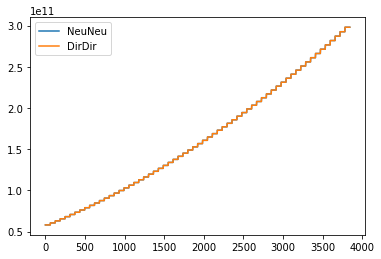

In [8]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

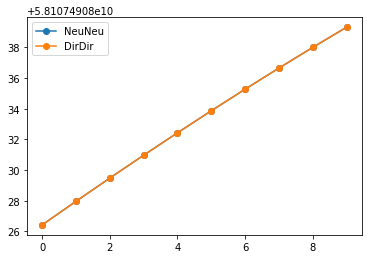

In [9]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [10]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[5.810749082642307281494140625000e+10 5.810749082796354675292968750000e+10
 5.810749082947869873046875000000e+10 5.810749083096778869628906250000e+10
 5.810749083243089294433593750000e+10 5.810749083386724853515625000000e+10
 5.810749083527480316162109375000e+10 5.810749083665412902832031250000e+10
 5.810749083800179290771484375000e+10 5.810749083931920623779296875000e+10]
[5.810749082642343139648437500000e+10 5.810749082796293640136718750000e+10
 5.810749082947787475585937500000e+10 5.810749083096758270263671875000e+10
 5.810749083243090057373046875000e+10 5.810749083386713409423828125000e+10
 5.810749083527504730224609375000e+10 5.810749083665335845947265625000e+10
 5.810749083800163269042968750000e+10 5.810749083931846618652343750000e+10]


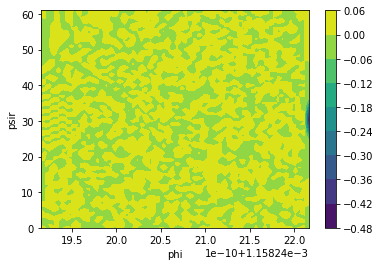

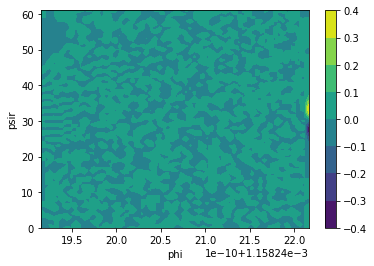

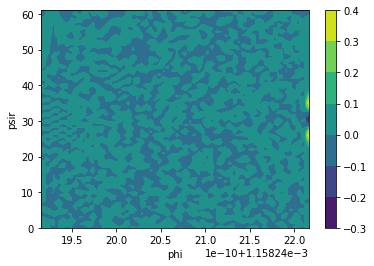

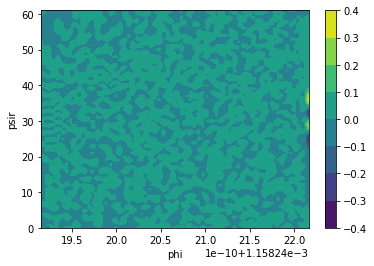

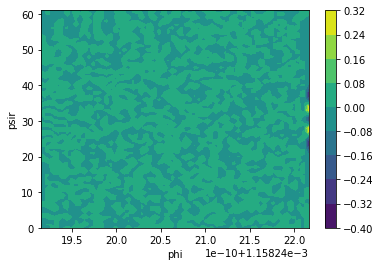

In [11]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], np.arange(nGrid-2), np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

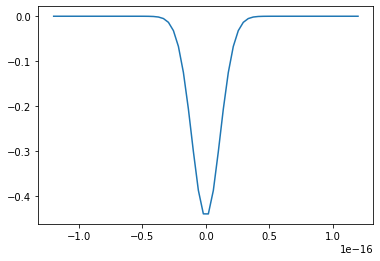

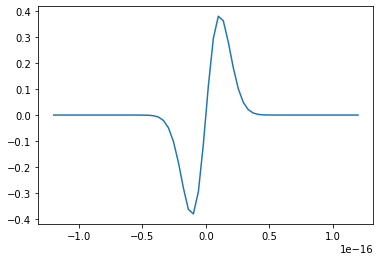

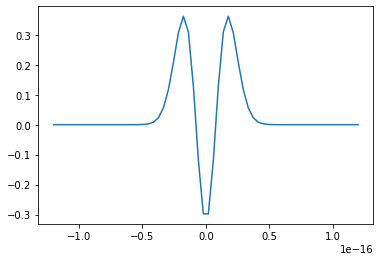

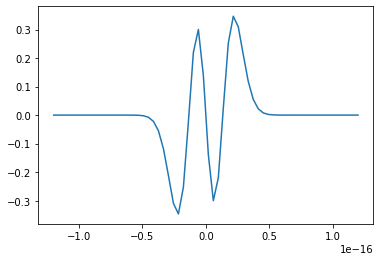

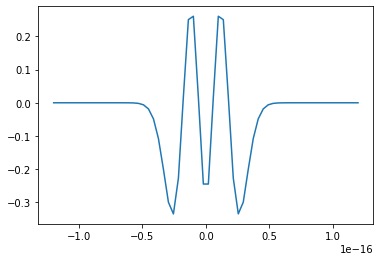

In [12]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir[1:-1], np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

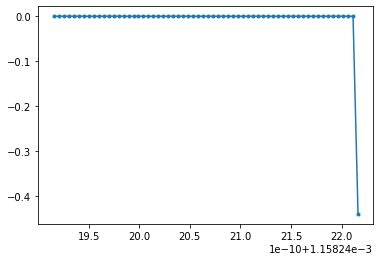

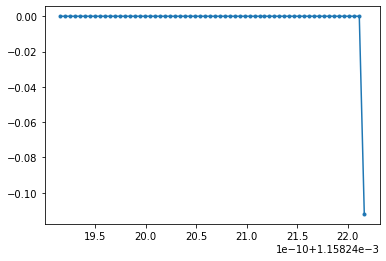

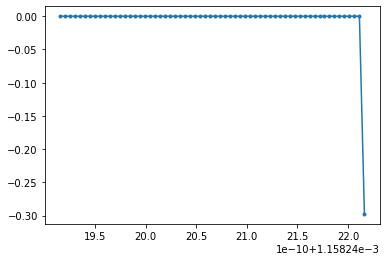

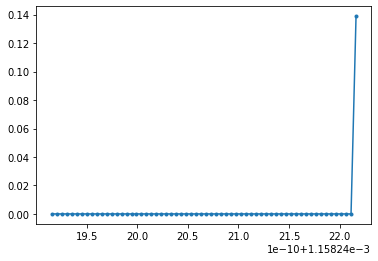

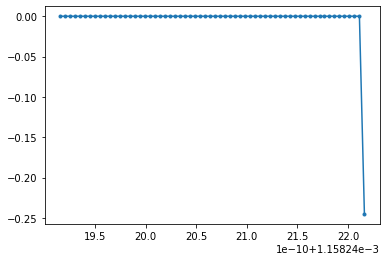

In [13]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi[1:-1], np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

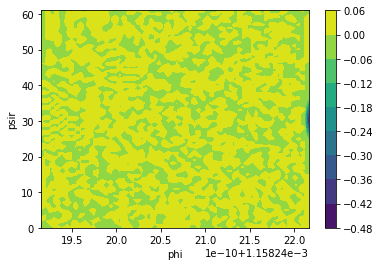

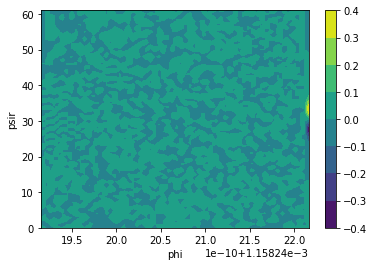

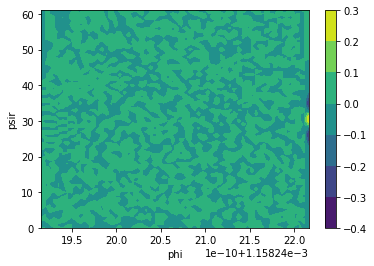

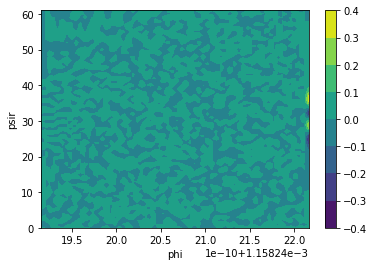

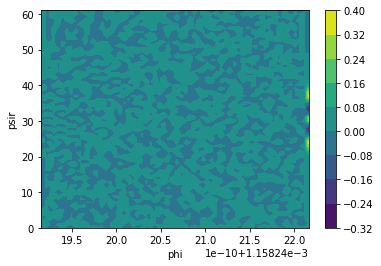

In [14]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], np.arange(nGrid-2), np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

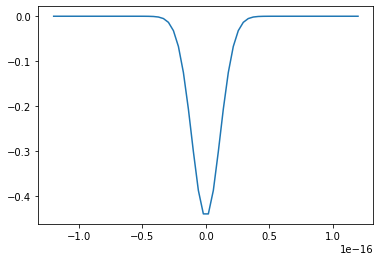

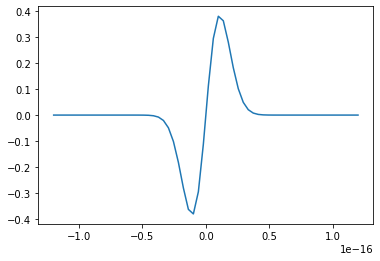

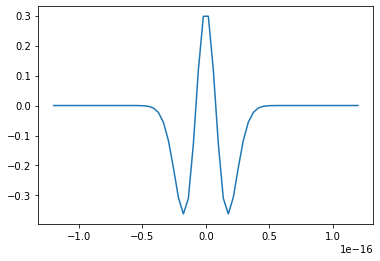

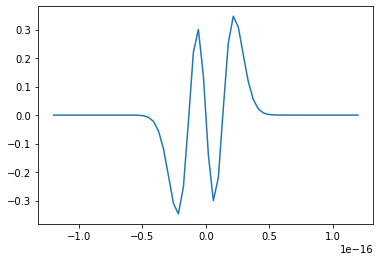

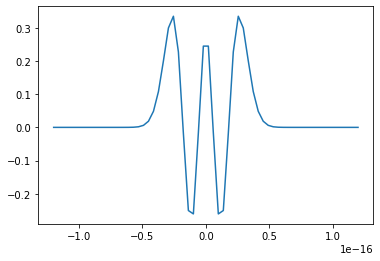

In [15]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir[1:-1], np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

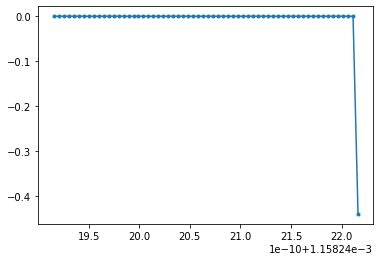

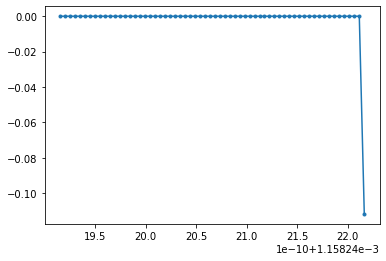

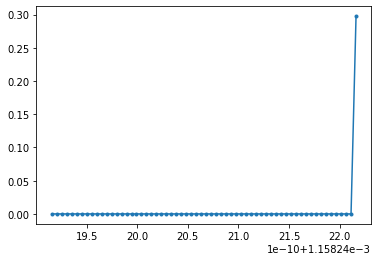

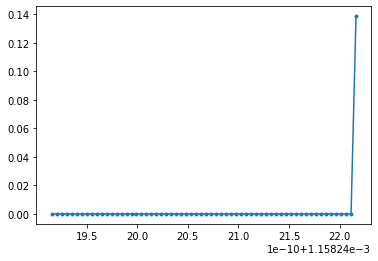

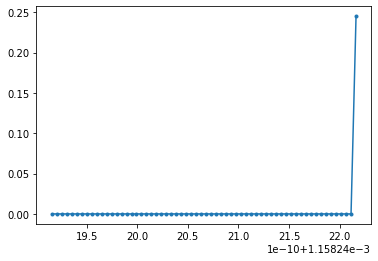

In [16]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi[1:-1], np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

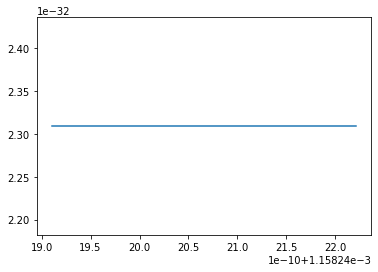

In [17]:
v_psi0 = [infPotFunc([phi, 0]) for phi in customGrid_phi]

ax = plt.gca()
plt.plot(customGrid_phi, v_psi0)
plt.show()

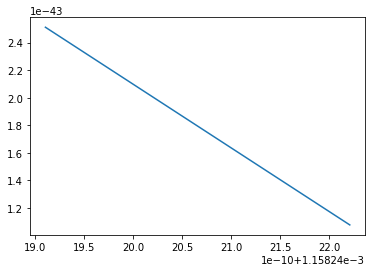

In [18]:
vDerphi_psi0 = [infPotDerivFunc_phi([phi, 0]) for phi in customGrid_phi]

ax = plt.gca()
plt.plot(customGrid_phi, vDerphi_psi0)
plt.show()

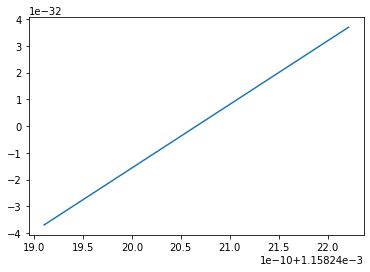

In [19]:
vDer2psi_psi0 = [infPotDeriv2Func_psir([phi, 0]) for phi in customGrid_phi]

ax = plt.gca()
plt.plot(customGrid_phi, vDer2psi_psi0)
plt.show()